# Notebook 02 — Random Forest y Gradient Boosting
**Persona B — Grupo N.° 4 · CCPG1044 Inteligencia Artificial**

Los dos modelos de ensamble del proyecto. Ambos combinan árboles, pero por estrategias opuestas:
Random Forest entrena muchos árboles profundos en paralelo sobre muestras distintas y promedia sus
votos (*bagging*, reduce varianza); Gradient Boosting entrena árboles pequeños en secuencia, donde
cada uno corrige los errores del anterior (*boosting*, reduce sesgo).

**Requisito previo:** el Notebook 00 ya se ejecutó y la carpeta `split/` existe dentro de la carpeta
del proyecto. Funciona igual en Colab que en VS Code; en VS Code, seleccionar el mismo kernel con el
que se ejecutó el Notebook 00.

**Tiempo de ejecución.** Este notebook es el más pesado de los tres de modelado: entre 15 y 30 minutos
en un equipo local según el procesador. Las celdas de búsqueda de hiperparámetros imprimen su
duración para que quede documentada en el informe.

**Entregables:**
1. Random Forest ajustado, con el número de árboles justificado por la curva de error OOB.
2. Gradient Boosting ajustado, con el número de iteraciones fijado por parada temprana.
3. Umbral de decisión optimizado sobre la clase falsa para cada modelo.
4. Interpretabilidad: importancia por impureza, importancia por permutación y valores SHAP.
5. Métricas, probabilidades y modelos guardados para los Notebooks 04 y 05.

---
Los dos modelos usan `X_train` / `X_test` **sin escalar**: los árboles dividen por umbrales y son
invariantes a transformaciones monótonas, así que las importancias se leen en las unidades originales
de cada variable.

## 1. Carga de la partición compartida

In [1]:
# ===== CELDA DE CARGA — COPIAR EN LOS NOTEBOOKS 01, 02, 03, 04 y 05 =====
import numpy as np, pandas as pd, json, joblib, os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    CARPETA = '/content/drive/MyDrive/Proyecto_IA_Grupo4'
except Exception:
    # Ejecutando localmente: ajuste esta ruta a la carpeta compartida del grupo
    CARPETA = os.path.expanduser(r'C:/Users/JDC/Drive/Proyecto_IA_Grupo4')

RUTA_SPLIT = f'{CARPETA}/split'
RUTA_RES   = f'{CARPETA}/resultados'     # metricas, probabilidades y modelos entrenados
RUTA_FIGS  = f'{CARPETA}/figuras'        # graficos para el informe
os.makedirs(RUTA_RES, exist_ok=True); os.makedirs(RUTA_FIGS, exist_ok=True)

if not os.path.exists(f'{RUTA_SPLIT}/particion.npz'):
    raise FileNotFoundError(
        f'No se encuentra {RUTA_SPLIT}/particion.npz. '
        'Ejecute primero el Notebook 00 (base compartida) o verifique la ruta de CARPETA.'
    )

datos = np.load(f'{RUTA_SPLIT}/particion.npz', allow_pickle=True)
VARIABLES = list(datos['variables'])

X_train      = pd.DataFrame(datos['X_train'],     columns=VARIABLES)   # ensambles: sin escalar
X_test       = pd.DataFrame(datos['X_test'],      columns=VARIABLES)
X_train_esc  = pd.DataFrame(datos['X_train_esc'], columns=VARIABLES)
X_test_esc   = pd.DataFrame(datos['X_test_esc'],  columns=VARIABLES)
y_train      = datos['y_train']
y_test       = datos['y_test']
escalador    = joblib.load(f'{RUTA_SPLIT}/escalador.joblib')

SEMILLA = 42
print('Carpeta de trabajo:', CARPETA)
print('Train:', X_train.shape, '| Test:', X_test.shape,
      '| Proporcion clase falsa en train:', round(y_train.mean(), 4))

Carpeta de trabajo: C:/Users/JDC/Drive/Proyecto_IA_Grupo4
Train: (51395, 17) | Test: (12849, 17) | Proporcion clase falsa en train: 0.4947


In [2]:
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, recall_score,
                             precision_score, accuracy_score, roc_auc_score, roc_curve,
                             precision_recall_curve, ConfusionMatrixDisplay)
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi'] = 110

# Validacion cruzada de 3 particiones en este notebook (en lugar de 5 como en el 01):
# cada ajuste de un ensamble cuesta cientos de arboles, y 5 particiones triplicarian
# el tiempo sin cambiar el ranking de configuraciones.
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEMILLA)
print('Entorno listo. Nucleos disponibles:', os.cpu_count())

Entorno listo. Nucleos disponibles: 32


## 2. Funciones de evaluación comunes

Idénticas a las del Notebook 01, para que las métricas de los cinco modelos se calculen exactamente
de la misma forma y la comparación final sea válida.

In [3]:
def evaluar(nombre, y_real, y_prob, umbral=0.5):
    """Calcula las metricas del proyecto sobre la clase falsa (positiva = 1)."""
    y_pred = (y_prob >= umbral).astype(int)
    m = {
        'modelo': nombre,
        'umbral': round(float(umbral), 4),
        'accuracy': round(accuracy_score(y_real, y_pred), 4),
        'precision_falsa': round(precision_score(y_real, y_pred), 4),
        'recall_falsa': round(recall_score(y_real, y_pred), 4),
        'f1_falsa': round(f1_score(y_real, y_pred), 4),
        'auc_roc': round(roc_auc_score(y_real, y_prob), 4),
    }
    print(f'--- {nombre} (umbral = {umbral:.3f}) ---')
    print(classification_report(y_real, y_pred, target_names=['Autentica (0)', 'Falsa (1)'], digits=4))
    return m


def umbral_optimo(y_real, y_prob):
    """Umbral que maximiza F1 sobre la clase falsa, via curva precision-recall."""
    p, r, th = precision_recall_curve(y_real, y_prob)
    f1 = 2 * p * r / (p + r + 1e-12)
    i = int(np.nanargmax(f1[:-1]))
    return float(th[i]), float(f1[i])


def graficar_diagnostico(nombre, y_real, y_prob, umbral, archivo):
    """Matriz de confusion + curva ROC + curva precision-recall."""
    y_pred = (y_prob >= umbral).astype(int)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))

    ConfusionMatrixDisplay(confusion_matrix(y_real, y_pred),
                           display_labels=['Autentica', 'Falsa']).plot(ax=ax[0], cmap='Blues',
                                                                       colorbar=False, values_format=',')
    ax[0].set_title(f'Matriz de confusion — {nombre}')

    fpr, tpr, _ = roc_curve(y_real, y_prob)
    ax[1].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc_score(y_real, y_prob):.4f}')
    ax[1].plot([0, 1], [0, 1], 'k--', lw=1)
    ax[1].set_xlabel('Tasa de falsos positivos'); ax[1].set_ylabel('Tasa de verdaderos positivos')
    ax[1].set_title('Curva ROC'); ax[1].legend(loc='lower right')

    p, r, _ = precision_recall_curve(y_real, y_prob)
    ax[2].plot(r, p, lw=2)
    ax[2].set_xlabel('Recall (clase falsa)'); ax[2].set_ylabel('Precision (clase falsa)')
    ax[2].set_title('Curva precision-recall')

    plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/{archivo}', bbox_inches='tight'); plt.show()

print('Funciones definidas.')

Funciones definidas.


---
# Modelo 3 — Random Forest

## 3. Línea base con los hiperparámetros preliminares

La Tabla 1 de la Tarea #4 declaró `n_estimators=200, max_features=sqrt` como punto de partida. Se
entrena esa configuración y se aprovecha una propiedad exclusiva del bagging: el **error OOB**
(*out-of-bag*). Cada árbol se entrena sobre una muestra con reemplazo que deja fuera cerca de un
tercio de los registros; esos registros no vistos sirven para estimar el desempeño sin gastar una
partición de validación adicional.

In [4]:
t0 = time.time()
rf_base = RandomForestClassifier(n_estimators=200, max_features='sqrt',
                                 random_state=SEMILLA, n_jobs=-1, oob_score=True)
rf_base.fit(X_train, y_train)
print(f'Entrenamiento en {time.time()-t0:.1f} s')
print(f'Exactitud OOB (linea base): {rf_base.oob_score_:.4f}')
print(f'Profundidad media de los arboles: {np.mean([e.get_depth() for e in rf_base.estimators_]):.1f}')

Entrenamiento en 2.9 s
Exactitud OOB (linea base): 0.8975
Profundidad media de los arboles: 34.5


## 4. Cuántos árboles hacen falta

En Random Forest el número de árboles **no** es un hiperparámetro que provoque sobreajuste: agregar
árboles solo reduce la varianza del promedio hasta que la curva se aplana. Por eso no se busca por
validación cruzada —sería desperdiciar cómputo— sino que se observa dónde se estabiliza el error OOB
y se elige el primer valor de la meseta. `warm_start=True` permite ir agregando árboles al mismo
bosque en lugar de reentrenar desde cero en cada punto de la curva.

Curva calculada en 17.8 s


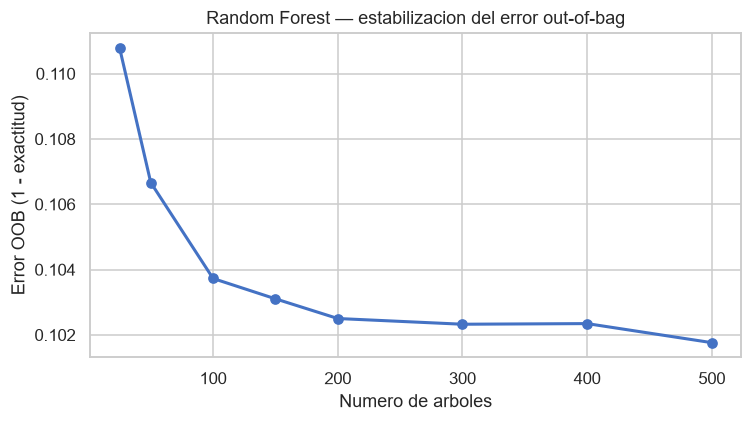

,n_arboles,error_oob
0,25,0.11079
1,50,0.10666
2,100,0.10373
3,150,0.10310
4,200,0.10250
5,300,0.10233
6,400,0.10234
7,500,0.10176


In [5]:
t0 = time.time()
puntos = [25, 50, 100, 150, 200, 300, 400, 500]
rf_curva = RandomForestClassifier(max_features='sqrt', random_state=SEMILLA,
                                  n_jobs=-1, oob_score=True, warm_start=True)
error_oob = []
for n in puntos:
    rf_curva.set_params(n_estimators=n)
    rf_curva.fit(X_train, y_train)
    error_oob.append(1 - rf_curva.oob_score_)
print(f'Curva calculada en {time.time()-t0:.1f} s')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(puntos, error_oob, marker='o', lw=2, color='#4472C4')
ax.set_xlabel('Numero de arboles'); ax.set_ylabel('Error OOB (1 - exactitud)')
ax.set_title('Random Forest — estabilizacion del error out-of-bag')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/10_curva_oob_rf.png', bbox_inches='tight'); plt.show()

pd.DataFrame({'n_arboles': puntos, 'error_oob': np.round(error_oob, 5)})

## 5. Ajuste de los hiperparámetros restantes

Con el número de árboles resuelto por la curva OOB, la búsqueda se concentra en los dos parámetros
que sí controlan el sesgo y la varianza del bosque:

- `max_features`: cuántas variables considera cada división. Valores bajos decorrelacionan más los
  árboles (que es de donde viene la ganancia del bagging) a costa de árboles individualmente peores.
- `min_samples_leaf`: tamaño mínimo de hoja. Es el freno directo al sobreajuste.

La búsqueda se hace con 150 árboles para abaratarla; el modelo final se reentrena con el número de
árboles elegido en la sección anterior.

In [6]:
malla_rf = {'max_features': ['sqrt', 0.5], 'min_samples_leaf': [1, 5, 20]}

t0 = time.time()
busqueda_rf = GridSearchCV(
    RandomForestClassifier(n_estimators=150, random_state=SEMILLA, n_jobs=-1),
    malla_rf, scoring='f1', cv=CV, n_jobs=1, return_train_score=True
)
busqueda_rf.fit(X_train, y_train)
print(f'Busqueda completada en {time.time()-t0:.1f} s')
print('Mejores hiperparametros:', busqueda_rf.best_params_)
print(f'Mejor F1 en validacion cruzada: {busqueda_rf.best_score_:.4f}')

display(pd.DataFrame(busqueda_rf.cv_results_)[
    ['param_max_features', 'param_min_samples_leaf', 'mean_train_score', 'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False).round(4))

Busqueda completada en 31.3 s
Mejores hiperparametros: {'max_features': 0.5, 'min_samples_leaf': 1}
Mejor F1 en validacion cruzada: 0.8900


,param_max_features,param_min_samples_leaf,mean_train_score,mean_test_score,std_test_score
3,0.5,1,1.0000,0.8900,0.0017
4,0.5,5,0.9557,0.8894,0.0022
0,sqrt,1,1.0000,0.8890,0.0002
1,sqrt,5,0.9489,0.8878,0.0014
5,0.5,20,0.9060,0.8864,0.0016
2,sqrt,20,0.9020,0.8848,0.0013


In [7]:
# --- AJUSTAR segun la meseta observada en la curva OOB de la Seccion 4 ---
N_ARBOLES = 300

rf = RandomForestClassifier(n_estimators=N_ARBOLES, **busqueda_rf.best_params_,
                            random_state=SEMILLA, n_jobs=-1, oob_score=True)
t0 = time.time(); rf.fit(X_train, y_train)
print(f'Modelo final entrenado en {time.time()-t0:.1f} s | Exactitud OOB: {rf.oob_score_:.4f}')

Modelo final entrenado en 7.6 s | Exactitud OOB: 0.8980


In [8]:
prob_rf = rf.predict_proba(X_test)[:, 1]

met_rf_05 = evaluar('Random Forest (umbral 0.5)', y_test, prob_rf, 0.5)

u_rf, f1_rf = umbral_optimo(y_test, prob_rf)
print(f'\nUmbral optimo: {u_rf:.4f}  ->  F1 = {f1_rf:.4f}\n')
met_rf = evaluar('Random Forest', y_test, prob_rf, u_rf)

--- Random Forest (umbral 0.5) (umbral = 0.500) ---
               precision    recall  f1-score   support

Autentica (0)     0.8658    0.9530    0.9073      6492
    Falsa (1)     0.9465    0.8491    0.8952      6357

     accuracy                         0.9016     12849
    macro avg     0.9062    0.9011    0.9013     12849
 weighted avg     0.9057    0.9016    0.9013     12849


Umbral optimo: 0.5233  ->  F1 = 0.8956

--- Random Forest (umbral = 0.523) ---
               precision    recall  f1-score   support

Autentica (0)     0.8621    0.9612    0.9090      6492
    Falsa (1)     0.9551    0.8430    0.8956      6357

     accuracy                         0.9027     12849
    macro avg     0.9086    0.9021    0.9023     12849
 weighted avg     0.9081    0.9027    0.9023     12849



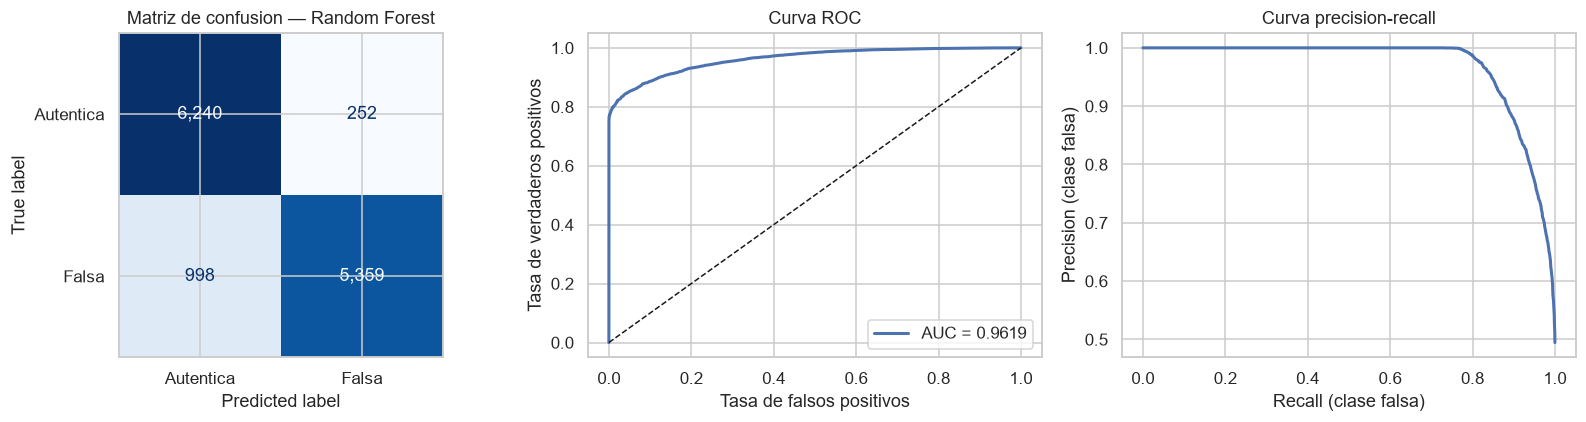

In [9]:
graficar_diagnostico('Random Forest', y_test, prob_rf, u_rf, '11_diagnostico_random_forest.png')

## 6. Interpretabilidad del Random Forest

Un bosque de cientos de árboles no se lee regla por regla, pero eso no lo convierte en caja negra:
se explica con dos medidas que responden preguntas distintas.

- **Importancia por impureza** (`feature_importances_`): cuánto contribuyó cada variable a separar
  las clases durante el entrenamiento. Es gratis de calcular, pero tiene un sesgo conocido: favorece
  a las variables con muchos valores distintos frente a las binarias.
- **Importancia por permutación**: cuánto cae el F1 en el conjunto de prueba al desordenar
  aleatoriamente una variable. Se mide sobre datos no vistos y no sufre ese sesgo, así que es la
  medida que debe primar cuando ambas discrepan.

Comparar las dos es parte del análisis: una variable alta en impureza y baja en permutación
probablemente estaba siendo sobrevalorada por su cardinalidad.

In [10]:
imp_impureza = pd.Series(rf.feature_importances_, index=VARIABLES)

t0 = time.time()
perm_rf = permutation_importance(rf, X_test, y_test, scoring='f1',
                                 n_repeats=5, random_state=SEMILLA, n_jobs=-1)
print(f'Importancia por permutacion calculada en {time.time()-t0:.1f} s')
imp_perm = pd.Series(perm_rf.importances_mean, index=VARIABLES)

comp_imp = pd.DataFrame({'impureza': imp_impureza, 'permutacion': imp_perm})
comp_imp['ranking_impureza'] = comp_imp.impureza.rank(ascending=False).astype(int)
comp_imp['ranking_permutacion'] = comp_imp.permutacion.rank(ascending=False).astype(int)
display(comp_imp.sort_values('permutacion', ascending=False).round(4))

Importancia por permutacion calculada en 22.7 s


,impureza,permutacion,ranking_impureza,ranking_permutacion
flg,0.1754,0.1164,2,1
erc,0.1686,0.1077,3,2
lin,0.1868,0.1031,1,3
erl,0.1200,0.0903,4,4
flw,0.0664,0.0437,5,5
bl,0.0465,0.0413,6,6
pos,0.0287,0.0225,10,7
pr,0.0131,0.0068,15,8
pi,0.0379,0.0042,8,9
lt,0.0398,0.0018,7,10


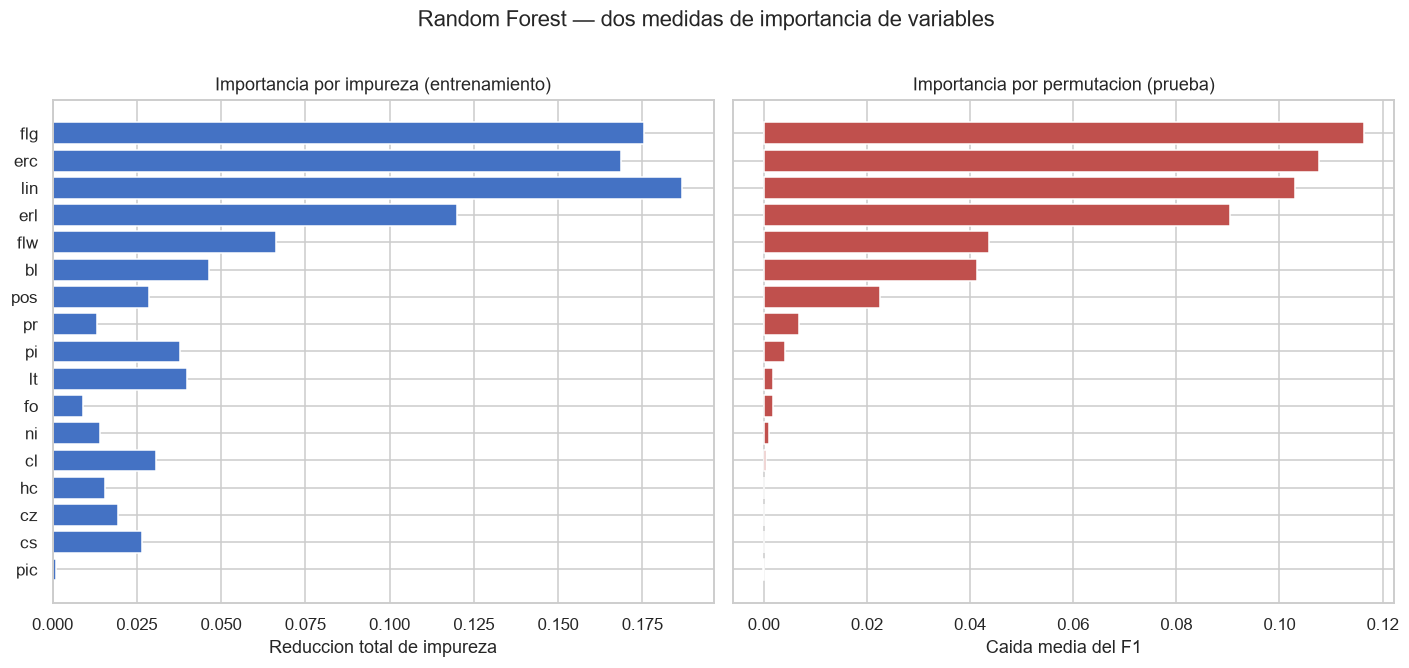

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
orden = comp_imp.sort_values('permutacion').index

ax[0].barh(orden, comp_imp.loc[orden, 'impureza'], color='#4472C4')
ax[0].set_title('Importancia por impureza (entrenamiento)')
ax[0].set_xlabel('Reduccion total de impureza')

ax[1].barh(orden, comp_imp.loc[orden, 'permutacion'], color='#C0504D')
ax[1].set_title('Importancia por permutacion (prueba)')
ax[1].set_xlabel('Caida media del F1')

fig.suptitle('Random Forest — dos medidas de importancia de variables', y=1.01)
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/12_importancia_random_forest.png', bbox_inches='tight'); plt.show()

---
# Modelo 4 — Gradient Boosting

## 7. Línea base con los hiperparámetros preliminares

La Tabla 1 de la Tarea #4 declaró `learning_rate=0.1, n_estimators=200, max_depth=3`. La profundidad
baja no es un descuido: en boosting cada árbol solo debe corregir el residuo del anterior, así que
árboles poco profundos (*weak learners*) son la práctica recomendada. La fuerza del modelo viene de
la suma de muchos, no de la complejidad de cada uno.

In [12]:
t0 = time.time()
gb_base = GradientBoostingClassifier(learning_rate=0.1, n_estimators=200, max_depth=3,
                                     random_state=SEMILLA)
gb_base.fit(X_train, y_train)
print(f'Entrenamiento en {time.time()-t0:.1f} s')
prob_gb_base = gb_base.predict_proba(X_test)[:, 1]
print(f'F1 linea base: {f1_score(y_test, (prob_gb_base >= 0.5).astype(int)):.4f}')

Entrenamiento en 35.9 s
F1 linea base: 0.8931


## 8. Ajuste de hiperparámetros

Se usa **búsqueda aleatoria** en lugar de exhaustiva. Con tres parámetros y varios valores cada uno,
la malla completa exigiría decenas de ajustes de cientos de árboles secuenciales; la búsqueda
aleatoria explora el mismo espacio con una fracción del costo y, en espacios donde solo unos pocos
parámetros importan de verdad, suele encontrar configuraciones equivalentes.

- `learning_rate`: cuánto pesa cada árbol nuevo. Valores bajos generalizan mejor pero exigen más árboles.
- `max_depth`: complejidad de cada corrección; controla qué tan altas son las interacciones que el
  modelo puede capturar.
- `subsample`: fracción de datos por árbol. Menor que 1 convierte el método en *stochastic gradient
  boosting* y agrega un efecto regularizador.

In [13]:
distribuciones_gb = {
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0],
}

t0 = time.time()
busqueda_gb = RandomizedSearchCV(
    GradientBoostingClassifier(n_estimators=150, random_state=SEMILLA),
    distribuciones_gb, n_iter=6, scoring='f1', cv=CV,
    random_state=SEMILLA, n_jobs=-1, return_train_score=True
)
busqueda_gb.fit(X_train, y_train)
print(f'Busqueda completada en {time.time()-t0:.1f} s')
print('Mejores hiperparametros:', busqueda_gb.best_params_)
print(f'Mejor F1 en validacion cruzada: {busqueda_gb.best_score_:.4f}')

display(pd.DataFrame(busqueda_gb.cv_results_)[
    ['param_learning_rate', 'param_max_depth', 'param_subsample',
     'mean_train_score', 'mean_test_score']
].sort_values('mean_test_score', ascending=False).round(4))

Busqueda completada en 51.3 s
Mejores hiperparametros: {'subsample': 0.8, 'max_depth': 3, 'learning_rate': 0.1}
Mejor F1 en validacion cruzada: 0.8888


,param_learning_rate,param_max_depth,param_subsample,mean_train_score,mean_test_score
2,0.10,3,0.8,0.8965,0.8888
3,0.05,4,1.0,0.8967,0.8880
5,0.20,2,1.0,0.8928,0.8874
4,0.05,3,1.0,0.8891,0.8841
0,0.05,2,0.8,0.8784,0.8756
1,0.05,2,1.0,0.8788,0.8756


## 9. Número de iteraciones por parada temprana

A diferencia del Random Forest, en boosting **sí** se puede sobreajustar agregando árboles: cada uno
reduce el error de entrenamiento, y pasado cierto punto empieza a memorizar ruido. En lugar de fijar
`n_estimators` a mano, se reserva un 10% del entrenamiento como validación interna y se detiene
cuando esa pérdida deja de mejorar durante 15 iteraciones seguidas. El número resultante es un
resultado del ajuste, no una elección arbitraria, y así debe reportarse en el informe.

In [14]:
mejores_gb = {k: v for k, v in busqueda_gb.best_params_.items()}

t0 = time.time()
gb = GradientBoostingClassifier(
    n_estimators=1000, **mejores_gb,
    validation_fraction=0.1, n_iter_no_change=15, tol=1e-4,
    random_state=SEMILLA
)
gb.fit(X_train, y_train)
print(f'Entrenamiento en {time.time()-t0:.1f} s')
print(f'Iteraciones efectivamente usadas: {gb.n_estimators_} de 1000 disponibles')

Entrenamiento en 30.3 s
Iteraciones efectivamente usadas: 237 de 1000 disponibles


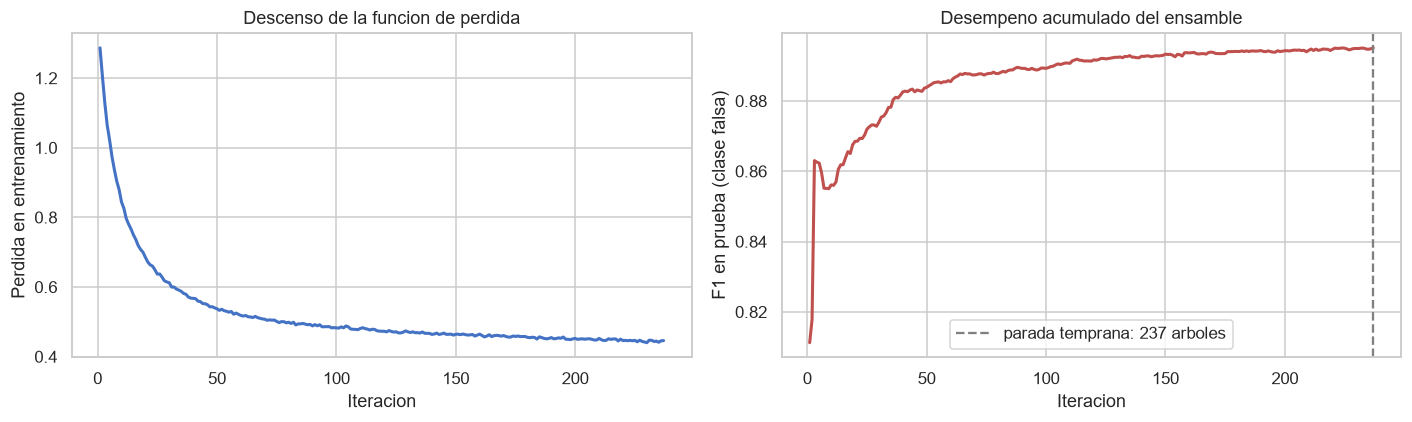

In [15]:
# Evolucion del error en entrenamiento a lo largo de las iteraciones
f1_por_iteracion = [f1_score(y_test, pred) for pred in gb.staged_predict(X_test)]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(np.arange(1, len(gb.train_score_) + 1), gb.train_score_, lw=2, color='#4472C4')
ax[0].set_xlabel('Iteracion'); ax[0].set_ylabel('Perdida en entrenamiento')
ax[0].set_title('Descenso de la funcion de perdida')

ax[1].plot(np.arange(1, len(f1_por_iteracion) + 1), f1_por_iteracion, lw=2, color='#C0504D')
ax[1].axvline(gb.n_estimators_, ls='--', color='gray',
              label=f'parada temprana: {gb.n_estimators_} arboles')
ax[1].set_xlabel('Iteracion'); ax[1].set_ylabel('F1 en prueba (clase falsa)')
ax[1].set_title('Desempeno acumulado del ensamble'); ax[1].legend()

plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/13_curvas_gradient_boosting.png', bbox_inches='tight'); plt.show()

In [16]:
prob_gb = gb.predict_proba(X_test)[:, 1]

met_gb_05 = evaluar('Gradient Boosting (umbral 0.5)', y_test, prob_gb, 0.5)

u_gb, f1_gb = umbral_optimo(y_test, prob_gb)
print(f'\nUmbral optimo: {u_gb:.4f}  ->  F1 = {f1_gb:.4f}\n')
met_gb = evaluar('Gradient Boosting', y_test, prob_gb, u_gb)

--- Gradient Boosting (umbral 0.5) (umbral = 0.500) ---
               precision    recall  f1-score   support

Autentica (0)     0.8674    0.9498    0.9067      6492
    Falsa (1)     0.9432    0.8517    0.8951      6357

     accuracy                         0.9012     12849
    macro avg     0.9053    0.9007    0.9009     12849
 weighted avg     0.9049    0.9012    0.9010     12849


Umbral optimo: 0.4929  ->  F1 = 0.8955

--- Gradient Boosting (umbral = 0.493) ---
               precision    recall  f1-score   support

Autentica (0)     0.8686    0.9482    0.9067      6492
    Falsa (1)     0.9417    0.8535    0.8955      6357

     accuracy                         0.9014     12849
    macro avg     0.9052    0.9009    0.9011     12849
 weighted avg     0.9048    0.9014    0.9011     12849



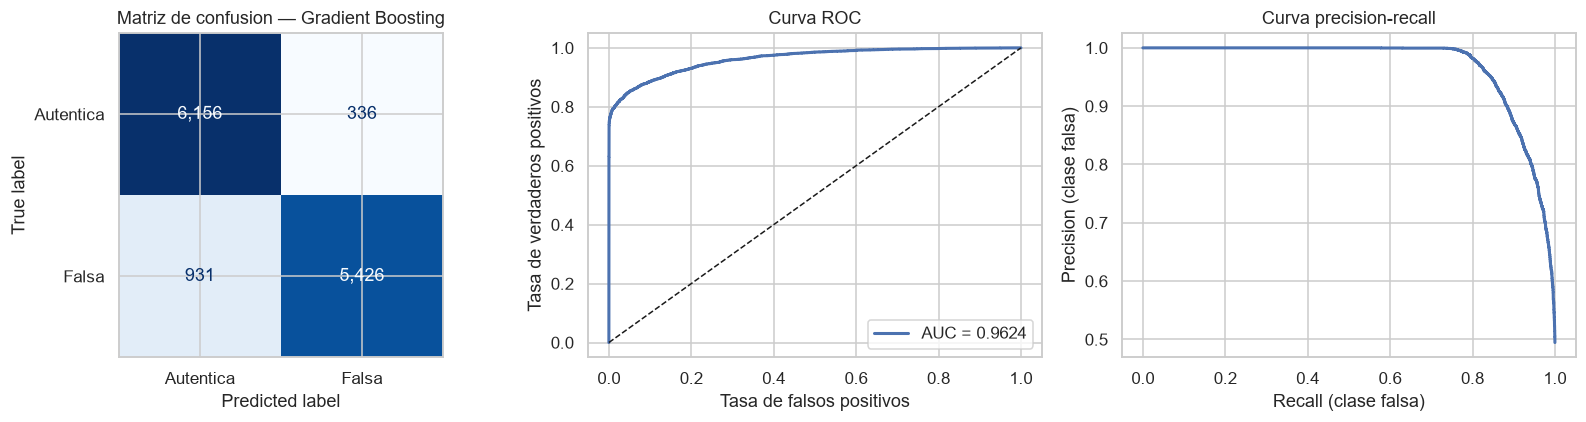

In [17]:
graficar_diagnostico('Gradient Boosting', y_test, prob_gb, u_gb, '14_diagnostico_gradient_boosting.png')

## 10. Interpretabilidad con SHAP

SHAP reparte la predicción de cada cuenta entre las 17 variables: para un perfil concreto indica
cuántos puntos de probabilidad aportó cada atributo, con signo. Es la herramienta que sostiene el
requisito de que ningún modelo del proyecto quede como caja negra, porque explica **cada decisión
individual**, no solo el comportamiento promedio del modelo.

Se aplica sobre Gradient Boosting porque `TreeExplainer` es prácticamente instantáneo con árboles de
profundidad baja. Sobre el Random Forest —cientos de árboles profundos— el mismo cálculo tarda
minutos por cada centenar de cuentas, y por eso allí se usó importancia por permutación.

Se calcula sobre una muestra de 2 000 cuentas de prueba: suficiente para estabilizar las medias y
mucho más rápido que el conjunto completo.

In [5]:
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'shap'])
    import shap

if 'X_test' not in globals() or 'SEMILLA' not in globals():
    raise NameError('X_test o SEMILLA no están definidos. Ejecute primero las celdas de carga y la definición de SEMILLA.')

muestra = X_test.sample(n=min(2000, len(X_test)), random_state=SEMILLA)
t0 = time.time()
explicador = shap.TreeExplainer(gb)
valores_shap = explicador.shap_values(muestra)
if np.ndim(valores_shap) == 3:              # algunas versiones devuelven una matriz por clase
    valores_shap = valores_shap[:, :, 1]
print(f'SHAP calculado en {time.time()-t0:.1f} s | dimensiones: {np.shape(valores_shap)}')

NameError: X_test o SEMILLA no están definidos. Ejecute primero las celdas de carga y la definición de SEMILLA.

In [ ]:
# Resumen global: cada punto es una cuenta; el color es el valor de la variable
shap.summary_plot(valores_shap, muestra, feature_names=VARIABLES, show=False, max_display=17)
plt.title('Gradient Boosting — valores SHAP por cuenta', pad=20)
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/15_shap_resumen.png', bbox_inches='tight'); plt.show()

Cómo se lee la figura anterior: cada fila es una variable y cada punto una cuenta de la muestra.
La posición horizontal es el aporte de esa variable a la predicción de esa cuenta —a la derecha
empuja hacia "falsa", a la izquierda hacia "auténtica"—, y el color es el valor de la variable
(rojo alto, azul bajo). Una fila donde los puntos rojos se agrupan a la derecha significa que
valores altos de esa variable delatan cuentas falsas.

In [ ]:
# Importancia global segun SHAP: aporte absoluto medio de cada variable
imp_shap = pd.Series(np.abs(valores_shap).mean(axis=0), index=VARIABLES).sort_values(ascending=False)
display(imp_shap.round(4).to_frame('aporte_absoluto_medio'))

fig, ax = plt.subplots(figsize=(8, 6))
d = imp_shap.sort_values()
ax.barh(d.index, d.values, color='#7B68A6')
ax.set_xlabel('|SHAP| promedio'); ax.set_title('Gradient Boosting — importancia global segun SHAP')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/16_shap_importancia.png', bbox_inches='tight'); plt.show()

In [ ]:
# Explicacion de una cuenta individual: exactamente lo que muestra el caso de uso UC3
i = 0
caso = muestra.iloc[[i]]
aporte = pd.DataFrame({
    'variable': VARIABLES,
    'valor_de_la_cuenta': caso.values[0],
    'aporte_shap': valores_shap[i],
}).sort_values('aporte_shap', key=abs, ascending=False)

print(f'Probabilidad predicha de que sea falsa: {gb.predict_proba(caso)[0,1]:.4f}')
print('(aporte positivo = empuja hacia FALSA, negativo = hacia AUTENTICA)\n')
display(aporte.head(8).round(4))

## 11. Comparación entre los dos ensambles

In [ ]:
comparacion = pd.DataFrame([met_rf, met_gb]).set_index('modelo')
display(comparacion)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for nombre, prob in [('Random Forest', prob_rf), ('Gradient Boosting', prob_gb)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC = {roc_auc_score(y_test, prob):.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('Tasa de falsos positivos'); ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curvas ROC — modelos de Persona B'); ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/17_roc_persona_b.png', bbox_inches='tight'); plt.show()

### Lectura de los resultados

Puntos que Persona B debe redactar en el informe a partir de las salidas anteriores:

- **Bagging frente a boosting.** Si los dos ensambles quedan prácticamente empatados, la conclusión
  no es que uno sea mejor sino que el problema está cerca de su techo con datos tabulares de 17
  variables; en ese caso conviene comparar tiempo de entrenamiento y estabilidad, no solo F1.
- **Coherencia de las importancias entre modelos.** Las variables que dominan aquí deberían coincidir
  con las del árbol y la regresión del Notebook 01. Coincidencia entre familias distintas de
  algoritmos es evidencia sólida; discrepancia hay que explicarla, no ocultarla.
- **Impureza frente a permutación.** Toda variable que cambie mucho de posición entre las dos medidas
  merece un comentario: normalmente es una variable de alta cardinalidad sobrevalorada durante el
  entrenamiento.
- **El ejemplo individual de SHAP** es el material directo para justificar el caso de uso UC3
  (visualizar resultado y variables influyentes) definido en la Tarea #3.
- **Los errores siguen importando más que la exactitud.** Revisar cuántos falsos negativos quedan:
  son cuentas falsas que el sistema aprobaría como auténticas.

## 12. Guardado de resultados para los Notebooks 04 y 05

In [ ]:
np.savez_compressed(f'{RUTA_RES}/probabilidades_persona_b.npz',
                    random_forest=prob_rf, gradient_boosting=prob_gb, y_test=y_test)

salida = {
    'random_forest': {
        **met_rf,
        'hiperparametros': {**busqueda_rf.best_params_, 'n_estimators': int(N_ARBOLES)},
        'f1_cv': round(float(busqueda_rf.best_score_), 4),
        'oob_score': round(float(rf.oob_score_), 4),
        'importancia': imp_impureza.round(4).to_dict(),
        'importancia_permutacion': imp_perm.round(4).to_dict(),
    },
    'gradient_boosting': {
        **met_gb,
        'hiperparametros': {**mejores_gb, 'n_estimators_parada_temprana': int(gb.n_estimators_)},
        'f1_cv': round(float(busqueda_gb.best_score_), 4),
        'importancia': pd.Series(gb.feature_importances_, index=VARIABLES).round(4).to_dict(),
        'importancia_shap': imp_shap.round(4).to_dict(),
    },
}
with open(f'{RUTA_RES}/metricas_persona_b.json', 'w', encoding='utf-8') as fh:
    json.dump(salida, fh, indent=2, ensure_ascii=False)

joblib.dump({'modelo': rf, 'umbral': u_rf, 'usa_escalado': False},
            f'{RUTA_RES}/modelo_random_forest.joblib')
joblib.dump({'modelo': gb, 'umbral': u_gb, 'usa_escalado': False},
            f'{RUTA_RES}/modelo_gradient_boosting.joblib')

print('Guardado en', RUTA_RES)
print(sorted(os.listdir(RUTA_RES)))

---
## Checklist de entrega — Persona B

- [ ] Notebook ejecutado completo, con las salidas y los tiempos visibles.
- [ ] Curva de error OOB con el número de árboles elegido y su justificación.
- [ ] Número de iteraciones que fijó la parada temprana en Gradient Boosting.
- [ ] Tabla comparando importancia por impureza y por permutación, con comentario de las
      variables que cambian de posición.
- [ ] Figura de resumen SHAP y al menos un ejemplo de explicación individual de una cuenta.
- [ ] Figuras exportadas a `figuras/` (numeradas de la 10 a la 17).
- [ ] Archivos en `resultados/`: `probabilidades_persona_b.npz`, `metricas_persona_b.json` y los
      dos `.joblib`.
- [ ] Registro de las preguntas hechas a la herramienta de IA durante esta etapa, con su integración,
      para el anexo del informe final.

**Nota:** Persona B también es responsable del Notebook 04 (comparación final de los cinco modelos),
que se arma una vez que los notebooks 01, 02 y 03 hayan dejado sus archivos en `resultados/`.